In [ ]:
pip install matplotlib

In [ ]:
pip install pandas

In [ ]:
pip install --upgrade pip

In [ ]:
pip install seaborn

In [ ]:
pip install openpyxl

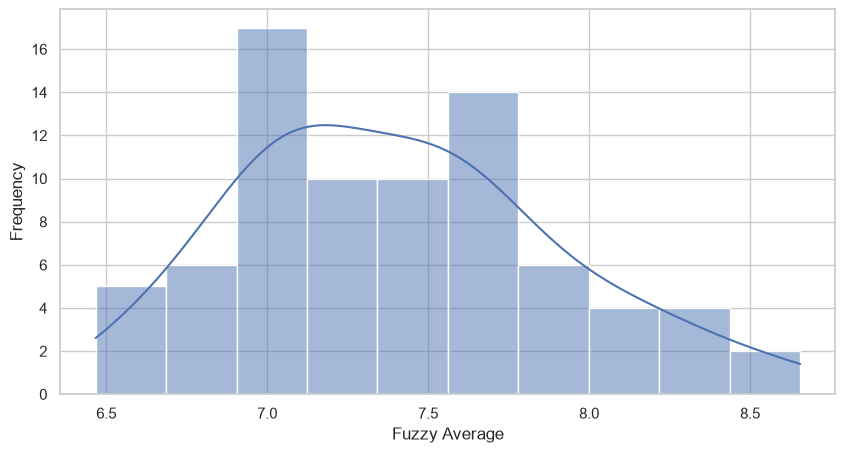

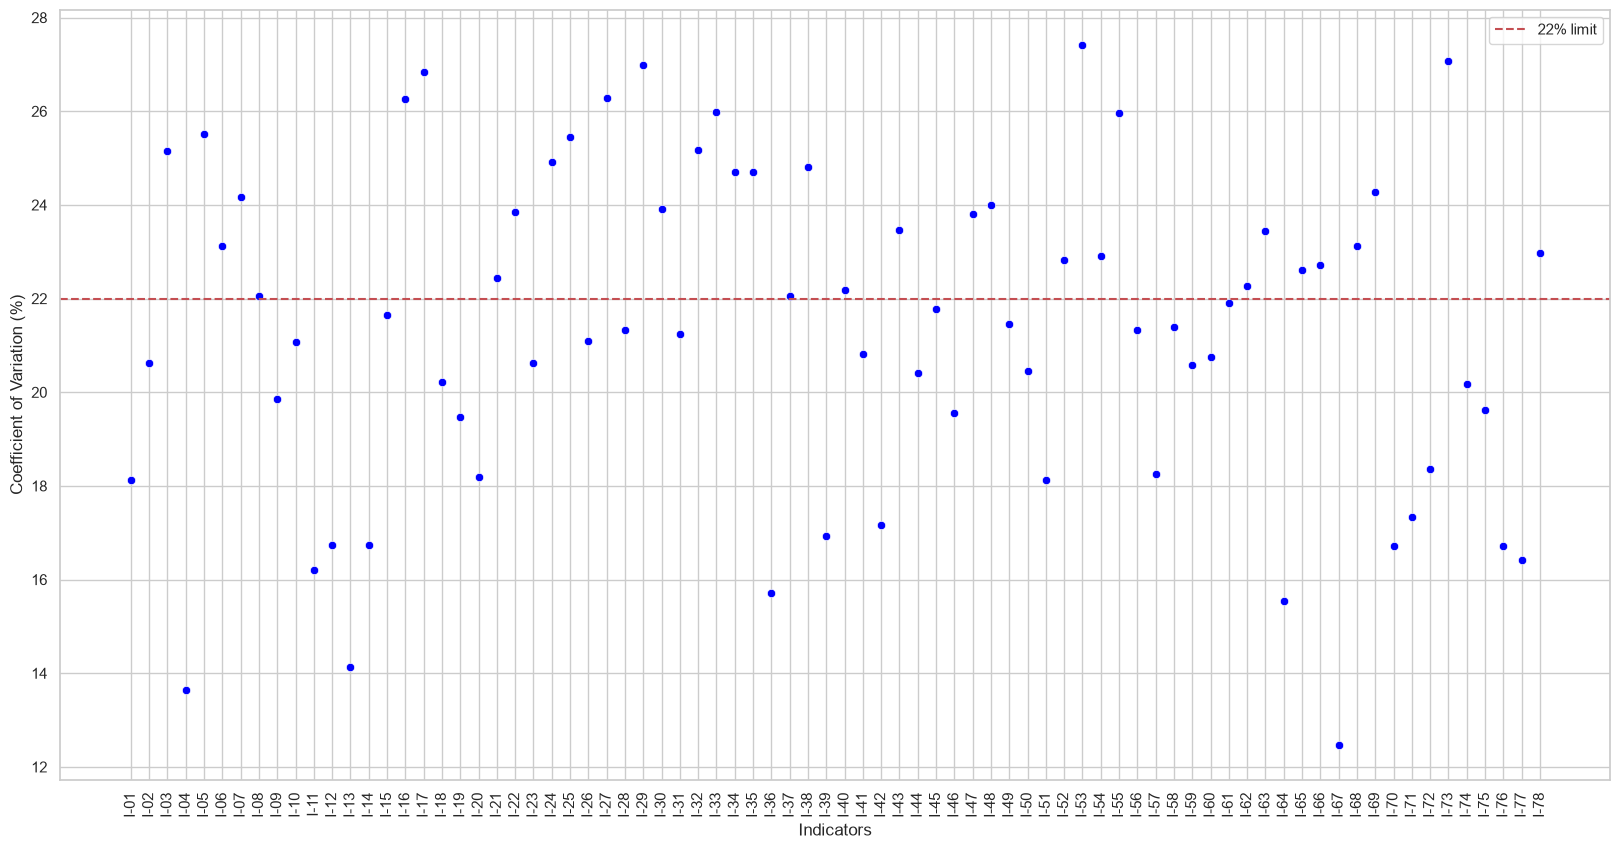

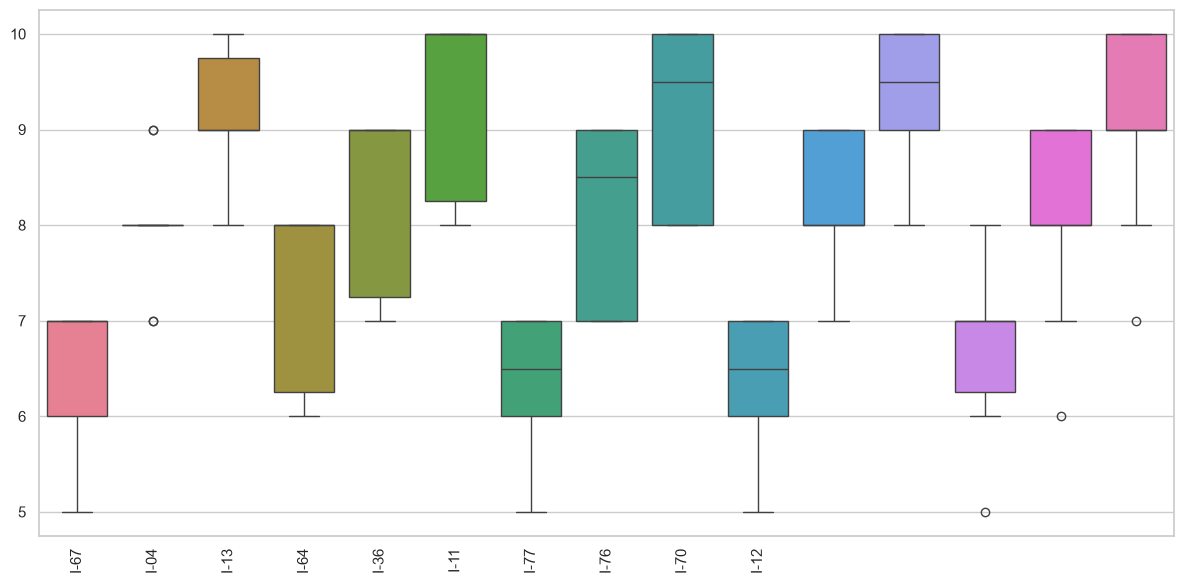

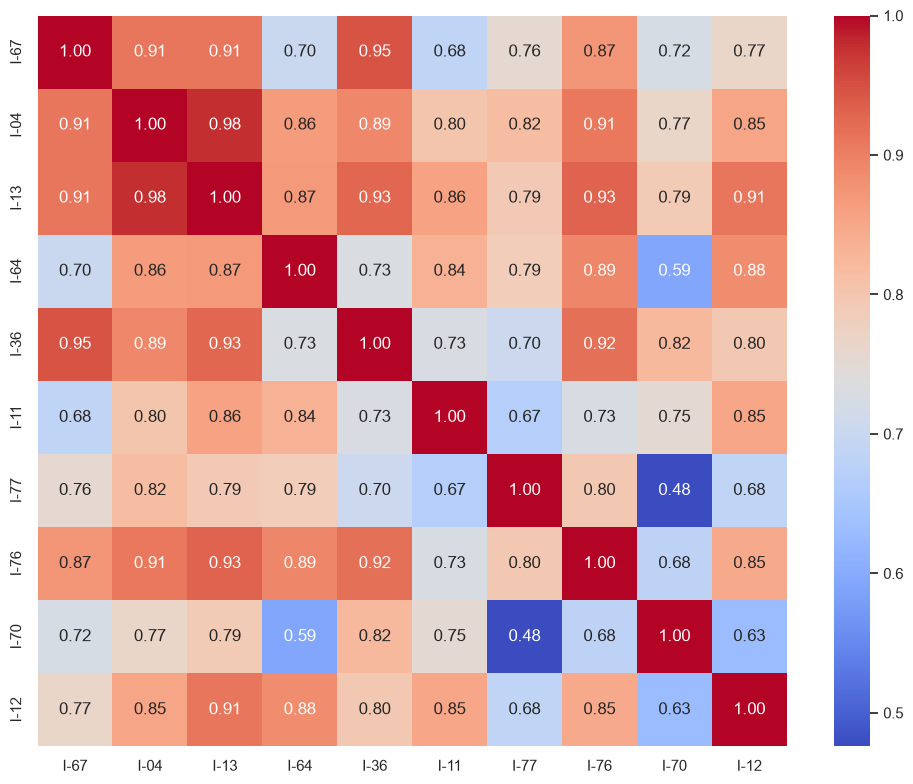

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
from openpyxl.styles import Font, Alignment, PatternFill

# Function to calculate the fuzzy triangular number (minimum, mean, maximum)
def calcular_fuzzy(valores):
    return (np.min(valores), np.mean(valores), np.max(valores))

# Defuzzification function using the weighted average
# (minimum + 4*mean + maximum) / 6
def defuzzificar(fuzzy):
    return (fuzzy[0] + 4*fuzzy[1] + fuzzy[2]) / 6

# Load the data
file_name = "dataset.xlsx"
df = pd.read_excel(file_name, sheet_name=0)

# Identify the indicators
indicadores = df.iloc[:, 0]

# Transform data for calculations
dados = df.iloc[:, 3:].values

# Apply the fuzzy calculation to each row
valores_fuzzy = np.array([calcular_fuzzy(linha) for linha in dados])
valores_defuzzificados = np.array([defuzzificar(fuzzy) for fuzzy in valores_fuzzy])

# Calculation of statistics
averages = valores_defuzzificados
desvios = np.std(dados, axis=1, ddof=1)
cv = (desvios / averages) * 100
minimos = valores_fuzzy[:, 0]
maximos = valores_fuzzy[:, 2]
medianas = np.median(dados, axis=1)

# Create a DataFrame with the results
resultados_df = pd.DataFrame({
    "Indicator": indicadores,
    "Minimum": minimos,
    "Maximum": maximos,
    "Fuzzy Average": averages,
    "Median": medianas,
    "Standard Deviation": desvios,
    "Coefficient of Variation (%)": cv
})

# Filter indicators with a coefficient of variation of less than 22%
selecionados = resultados_df[resultados_df["Coefficient of Variation (%)"] < 22.00]

# Create a new formatted Excel file
output_file = "results.xlsx"
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    resultados_df.to_excel(writer, sheet_name="Results", index=False)
    selecionados.to_excel(writer, sheet_name="Selected", index=False)

# Improve Excel formatting
wb = openpyxl.load_workbook(output_file)
ws = wb["Results"]
for col in ws.columns:
    for cell in col:
        cell.alignment = Alignment(horizontal='center')
        if cell.row == 1:
            cell.font = Font(bold=True)
            cell.fill = PatternFill(start_color="FFFF99", end_color="FFFF99", fill_type="solid")
wb.save(output_file)

# Graphics settings
sns.set(style="whitegrid")

# Select the 10 indicators with the lowest Coefficient of Variation.
top10_cv = resultados_df.sort_values(by="Coefficient of Variation (%)").head(10)

# Obtain corresponding indices and data
indices_top10 = top10_cv.index
dados_top10 = dados[indices_top10]
indicadores_top10 = indicadores.iloc[indices_top10]

# Create the Fig folder if it does not already exist.
Path("Fig").mkdir(exist_ok=True)

# Histogram of fuzzy means
graph_file1 = "Fig/fuzzy_means_histogram.png"
plt.figure(figsize=(10, 5))
sns.histplot(resultados_df["Fuzzy Average"], bins=10, kde=True)
#plt.title("Distribution of the Fuzzy Means of the Indicators")
plt.xlabel("Fuzzy Average")
plt.ylabel("Frequency")
plt.savefig(graph_file1, dpi=300, bbox_inches="tight")

# Scatter plot of the Coefficient of Variation
graph_file2 = "Fig/fuzzy_cv_dispersion.png"
plt.figure(figsize=(20, 10))
sns.scatterplot(x=resultados_df["Indicator"], y=resultados_df["Coefficient of Variation (%)"], color='blue')
plt.xticks(rotation=90)
#plt.title("Coefficient of Variation by Indicator (Fuzzy)")
plt.xlabel("Indicators")
plt.ylabel("Coefficient of Variation (%)")
plt.axhline(y=22, color='r', linestyle='--', label='22% limit')
plt.legend()
plt.savefig(graph_file2, dpi=300, bbox_inches="tight")

# Boxplot for data dispersion analysis
plt.figure(figsize=(12, 6))
sns.boxplot(data=dados_top10)
plt.xticks(ticks=range(len(indicadores_top10)), labels=indicadores_top10, rotation=90)
#plt.title("Boxplot of the 10 Indicators with the Lowest CV")
plt.tight_layout()
plt.savefig("Fig/boxplot_top10_cv.png", dpi=300, bbox_inches="tight")

# Correlation heatmap
corr_top10 = np.corrcoef(dados_top10)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_top10, annot=True, fmt=".2f", cmap="coolwarm", 
            xticklabels=indicadores_top10, yticklabels=indicadores_top10)
#plt.title("Correlation Matrix - Top 10 Indicators with the Lowest CV")
plt.tight_layout()
plt.savefig("Fig/heatmap_top10_cv.png", dpi=300, bbox_inches="tight")
